In [2]:
import temporalmapper as tm
import pandas as pd
import numpy as np
from tqdm import tqdm
from temporalmapper.chronoscope import Chronoscope
import temporalmapper.utilities as tmutils

In [3]:

scope = Chronoscope.load(
    "ttm-demo/UNGDC-demo-small/pickled"
)


Computing k nearest neighbours...
Computing spatial density...


Converting clusters to vertices: 100%|██████████| 14/14 [00:00<00:00, 1424.32it/s]


793 vertices added.


Adding edges: 100%|██████████| 13/13 [00:00<00:00, 14.25it/s]


Populating node centroids, colours, sizes...
Computing cluster colours...


...

Populating node centroids, colours, sizes...
Computing cluster colours...


Converting clusters to vertices: 100%|██████████| 14/14 [00:00<00:00, 2220.47it/s]


105 vertices added.


Adding edges: 100%|██████████| 13/13 [00:00<00:00, 19.25it/s]


Populating node centroids, colours, sizes...
Computing cluster colours...


In [62]:
cluster_trees=[]
for idx in range(len(scope.base_mapper.checkpoints)):
    cluster_tree_raw = scope.toponymies[idx].cluster_tree_  # {(layer, cluster): [children]}
    cluster_tree = {}

    # Initialize all nodes
    for parent, children in cluster_tree_raw.items():
        parent_key = f"{parent[0]}:{idx}:{parent[1]}"
        cluster_tree.setdefault(parent_key, {"parents": [], "children": []})
        for child in children:
            child_key = f"{child[0]}:{idx}:{child[1]}"
            cluster_tree.setdefault(child_key, {"parents": [], "children": []})

    # Fill parents and children
    for parent, children in cluster_tree_raw.items():
        parent_key = f"{parent[0]}:{idx}:{parent[1]}"
        for child in children:
            child_key = f"{child[0]}:{idx}:{child[1]}"
            cluster_tree[child_key]["parents"].append(parent_key)
            cluster_tree[parent_key]["children"].append(child_key)

    cluster_trees.append(cluster_tree)

In [63]:
scope.toponymies[0].cluster_tree_

{(1, 0): [(0, 1)],
 (1, 1): [(0, 4), (0, 3)],
 (1, 2): [(0, 8)],
 (1, 3): [(0, 9), (0, 10)],
 (1, 4): [(0, 11), (0, 12)],
 (1, 5): [(0, 13), (0, 14)],
 (1, 6): [(0, 17), (0, 16)],
 (1, 7): [(0, 33), (0, 22), (0, 32)],
 (1, 8): [(0, 23), (0, 26), (0, 25)],
 (1, 9): [(0, 34), (0, 35), (0, 28), (0, 36)],
 (1, 10): [(0, 31), (0, 30)],
 (1, 11): [(0, 38), (0, 39)],
 (1, 12): [(0, 37)],
 (1, 13): [(0, 40), (0, 41)],
 (1, 14): [(0, 45), (0, 47), (0, 46)],
 (1, 15): [(0, 43), (0, 44)],
 (2, 0): [(1, 3), (1, 2), (1, 4)],
 (2, 1): [(1, 9), (1, 10)],
 (2, 2): [(1, 8)],
 (2, 3): [(1, 13)],
 (2, 4): [(1, 14), (1, 15), (0, 42)],
 (3, 0): [(2, 0),
  (2, 1),
  (2, 2),
  (2, 3),
  (2, 4),
  (1, 0),
  (1, 1),
  (1, 5),
  (1, 6),
  (1, 7),
  (1, 11),
  (1, 12),
  (0, 0),
  (0, 2),
  (0, 5),
  (0, 6),
  (0, 7),
  (0, 15),
  (0, 18),
  (0, 19),
  (0, 20),
  (0, 21),
  (0, 24),
  (0, 27),
  (0, 29)]}

In [81]:

import networkx as nx
import plotly.graph_objects as go
from temporalmapper.utilities import *
from temporalmapper.analytics import *
def prepare_plotly_graph_objects(
    mapper,
    positions,
    cluster_labels = {},
    hover_text = {},
    edge_scaling: float = 1,
    node_scaling: float = 5,
    node_size_bounds: tuple[float] = (10,100),
    edge_weight_bounds: tuple[float] = (0.1,5),
    node_size_scale: str = 'sigmoid',
):
    # https://plotly.com/python/network-graphs/
    if type(positions) is str:
        positions = nx.get_node_attributes(mapper.G, positions)

    if len(hover_text)==0:
        # construct some default hover text.
        for node in mapper.G.nodes():
            idx = mapper.get_vertex_data(node)
            median_time = np.median(mapper.time[idx])
            node_name = cluster_labels.get(node,'')
            label_str = f"{node_name}<br>Node {node}<br>Time: {median_time}"
            hover_text[node] = label_str

        
    edge_traces = []
    G = mapper.G
    clr_dict = nx.get_node_attributes(G, "colour")
    weight = nx.get_edge_attributes(G, "weight")
    wmin, wmax = edge_weight_bounds
    edge_size_dict = {
        e:edge_scaling*np.clip(weight[e],wmin,wmax) for e in G.edges()
    }
    edge_info = {(edge[0],edge[1]):edge[2]
         for edge in scope.mappers[0].G.edges(data=True)}
    custom_data = pd.DataFrame(edge_info).T
    i=0
    for (u, v) in G.edges():
        edge_hover = f"{cluster_labels.get(u,'')}->{cluster_labels.get(v,'')}"
        x0, y0 = positions[u]
        x1, y1 = positions[v]
        edge_traces.append(
            go.Scatter(
                x=[x0, x1, None],
                y=[y0, y1, None],
                mode="lines",
                hoverinfo="text",
                line=dict(
                    width=edge_size_dict.get((u,v),'0.5'),
                    color=clr_dict.get(u,'black'),
                    ),
                customdata = custom_data.iloc[i],
                text = edge_hover,
            )
        )
        
    node_x = []
    node_y = []
    colours = []
    labels = []

    node_size = compute_node_size(
        mapper,
        G,
        node_scaling,
        node_size_scale,
        node_size_bounds
    )
    custom_data = pd.DataFrame(
        {node[0]:node[1] for node in mapper.G.nodes(data=True)}
    ).T
    # drop stuff that is going into the trace anyway
    # (i want to try and keep final filesize down)
    custom_data.drop("colour",axis=1,inplace=True)
    
    for node in G.nodes():
        x,y = positions[node]
        node_x.append(x)
        node_y.append(y)
        label_str = hover_text.get(node,'')
        labels.append(label_str)
        colours.append(G.nodes[node]['colour'])
    
    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        hoverinfo='text',
        marker=dict(
            showscale=False,
            size=node_size,
            sizemode='area',
            color=colours,
        ),
        customdata=custom_data,
        text=labels
    )
    return edge_traces, node_trace


import json
from pathlib import Path
import plotly.io as pio
def to_json(scope, cluster_labels={}, output_path: str = "chronoscope.json"):
    """
    Export all mapper graphs to JSON format compatible with Plotly.js
    Includes:
        - Nodes and edges per layer
        - Treemap data per layer per checkpoint
        - Cluster hierarchy across layers (cluster_trees)
    """

    graphs_data = []

    # Build cluster_trees once for all checkpoints
    cluster_trees = []
    for idx in range(len(scope.base_mapper.checkpoints)):
        cluster_tree_raw = scope.toponymies[idx].cluster_tree_  # {(layer, cluster): [children]}
        cluster_tree = {}
    
        # Initialize all nodes
        for parent, children in cluster_tree_raw.items():
            parent_key = f"{parent[0]}:{idx}:{parent[1]}"
            cluster_tree.setdefault(parent_key, {"parents": [], "children": []})
            for child in children:
                child_key = f"{child[0]}:{idx}:{child[1]}"
                cluster_tree.setdefault(child_key, {"parents": [], "children": []})
    
        # Fill parents and children
        for parent, children in cluster_tree_raw.items():
            parent_key = f"{parent[0]}:{idx}:{parent[1]}"
            for child in children:
                child_key = f"{child[0]}:{idx}:{child[1]}"
                cluster_tree[parent_key]["children"].append(child_key)
                if parent[0] != scope.n_layers:
                    cluster_tree[child_key]["parents"].append(parent_key)
               
        cluster_trees.append(cluster_tree)

    # Export data per layer
    for layer, mapper in scope.mappers.items():
        # Get cluster labels for this mapper
        cluster_labels = nx.get_node_attributes(mapper.G, 'topic_name')
        node_numbers = nx.get_node_attributes(mapper.G, 'node_number')

        # Prepare Plotly traces for network
        edge_traces, node_trace = prepare_plotly_graph_objects(
            mapper,
            'ts_pos',
            cluster_labels=cluster_labels,
            hover_text={},
        )

        # Prepare treemap data per checkpoint
        treemap_data = []
        for idx in range(len(mapper.checkpoints)):
            df = slice_df(mapper, idx)
            df = df.where(pd.notna(df), 0)
            df['layer'] = layer

            if 'node' in df.columns:
                df['topic_name'] = df['node'].map(cluster_labels)
                df['node_id'] = df['node'].map(node_numbers)

            treemap_data.append(df.to_dict('records'))

        # Compose graph data
        graph_data = {
            "layer": layer,
            "yaxis_ticks": [str(t) for t in mapper.checkpoints],
            "edges": [json.loads(pio.to_json(trace)) for trace in edge_traces],
            "nodes": json.loads(pio.to_json(node_trace)),
            "treemap_data": treemap_data,
            "cluster_trees": cluster_trees,   # same hierarchy for all layers
            "layout": {
                "title": f"Layer {layer}",
                "hovermode": "closest",
                "margin": {"b": 50, "l": 10, "r": 10, "t": 40},
                "xaxis": {"showgrid": True, "zeroline": False, "showticklabels": True},
                "yaxis": {"showgrid": False, "zeroline": False, "showticklabels": False},
                "showlegend": False,
            }
        }
        graphs_data.append(graph_data)

    # Write JSON
    output_file = Path(output_path)
    with open(output_file, 'w') as f:
        json.dump(graphs_data, f, indent=2)

    print(f"✓ Exported {len(graphs_data)} graph(s) to {output_file}")
    return output_file

In [82]:

to_json(scope)

✓ Exported 3 graph(s) to chronoscope.json


PosixPath('chronoscope.json')

In [83]:
scope.toponymies[0].cluster_tree_

{(1, 0): [(0, 1)],
 (1, 1): [(0, 4), (0, 3)],
 (1, 2): [(0, 8)],
 (1, 3): [(0, 9), (0, 10)],
 (1, 4): [(0, 11), (0, 12)],
 (1, 5): [(0, 13), (0, 14)],
 (1, 6): [(0, 17), (0, 16)],
 (1, 7): [(0, 33), (0, 22), (0, 32)],
 (1, 8): [(0, 23), (0, 26), (0, 25)],
 (1, 9): [(0, 34), (0, 35), (0, 28), (0, 36)],
 (1, 10): [(0, 31), (0, 30)],
 (1, 11): [(0, 38), (0, 39)],
 (1, 12): [(0, 37)],
 (1, 13): [(0, 40), (0, 41)],
 (1, 14): [(0, 45), (0, 47), (0, 46)],
 (1, 15): [(0, 43), (0, 44)],
 (2, 0): [(1, 3), (1, 2), (1, 4)],
 (2, 1): [(1, 9), (1, 10)],
 (2, 2): [(1, 8)],
 (2, 3): [(1, 13)],
 (2, 4): [(1, 14), (1, 15), (0, 42)],
 (3, 0): [(2, 0),
  (2, 1),
  (2, 2),
  (2, 3),
  (2, 4),
  (1, 0),
  (1, 1),
  (1, 5),
  (1, 6),
  (1, 7),
  (1, 11),
  (1, 12),
  (0, 0),
  (0, 2),
  (0, 5),
  (0, 6),
  (0, 7),
  (0, 15),
  (0, 18),
  (0, 19),
  (0, 20),
  (0, 21),
  (0, 24),
  (0, 27),
  (0, 29)]}

<Axes: >

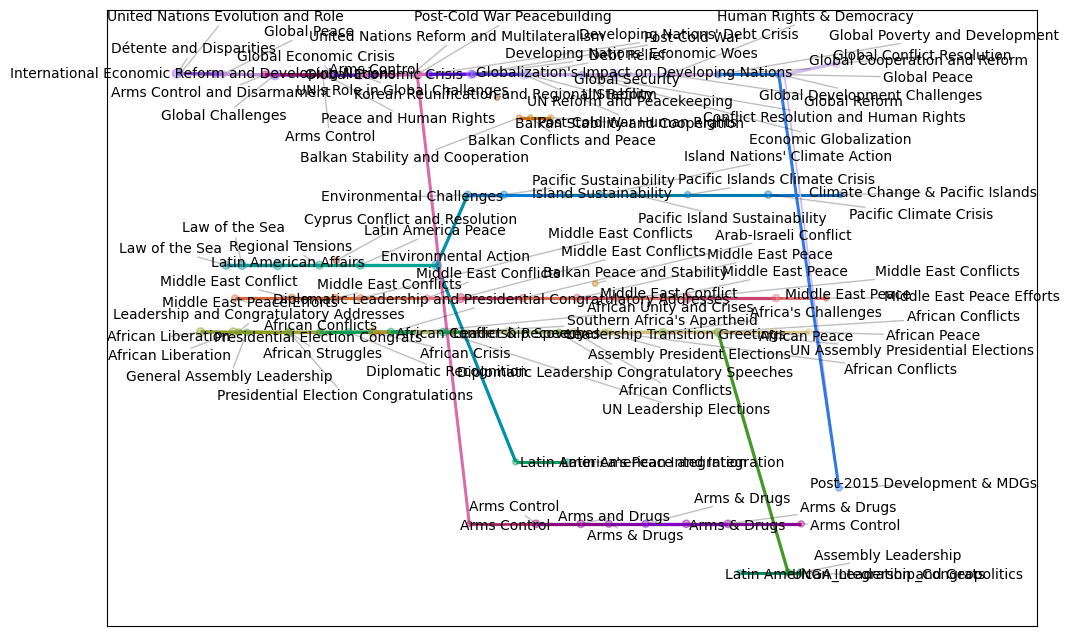

In [13]:
scope.mappers[2].temporal_plot(
    cluster_labels=nx.get_node_attributes(scope.mappers[2].G, 'topic_name')  
)

In [10]:
cluster_labels = nx.get_node_attributes(scope.mappers[2].G, 'topic_name')  
cluster_labels

{'0:0': 'Law of the Sea',
 '0:1': 'African Liberation',
 '0:2': 'Leadership and Congratulatory Addresses',
 '0:3': 'United Nations Evolution and Role',
 '0:4': 'Détente and Disparities',
 '1:0': 'Cyprus Conflict and Resolution',
 '1:1': 'Law of the Sea',
 '1:2': 'General Assembly Leadership',
 '1:3': 'African Liberation',
 '1:4': 'Middle East Peace Efforts',
 '1:5': 'International Economic Reform and Developing Nations',
 '1:6': 'Global Peace',
 '2:0': 'Latin American Affairs',
 '2:1': 'Presidential Election Congratulations',
 '2:2': 'African Struggles',
 '2:3': 'Middle East Conflict',
 '2:4': 'Global Challenges',
 '2:5': 'Arms Control and Disarmament',
 '3:0': 'Regional Tensions',
 '3:1': 'African Conflicts',
 '3:2': 'Presidential Election Congrats',
 '3:3': 'Middle East Conflicts',
 '3:4': 'Arms Control',
 '3:5': 'Peace and Human Rights',
 '3:6': 'Global Economic Crisis',
 '4:0': 'Latin America Peace',
 '4:1': 'Diplomatic Recognition',
 '4:2': 'African Crisis',
 '4:3': 'Middle East C

<Axes: >

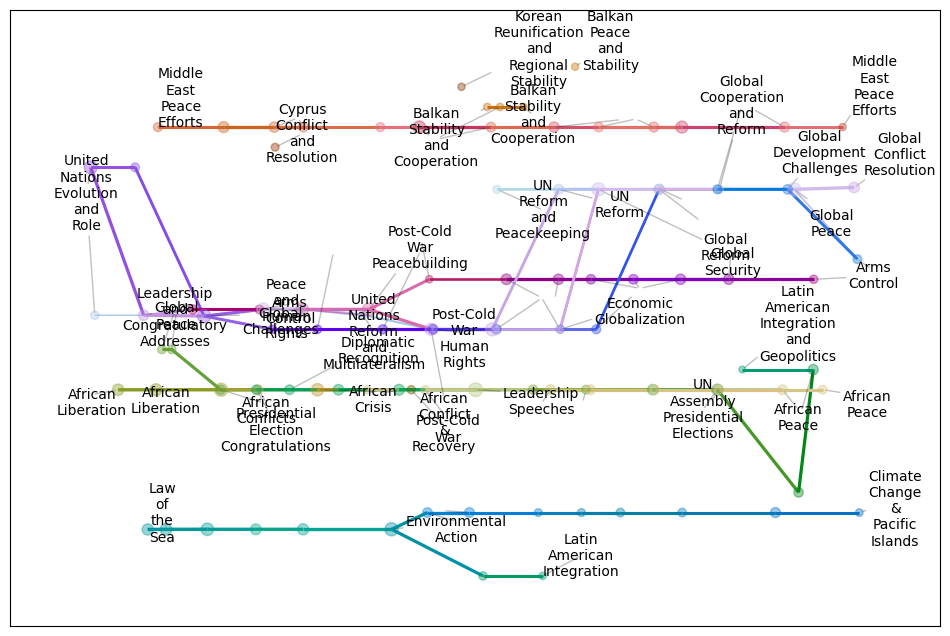

In [31]:
scope.temporal_plot(
    2,
    layout_optimization='ordered',
    #layout_optimization_kwargs={'spacing':0.2},
    node_size_bounds=(5,100),
    node_scaling = 5,
    hide_deg2_labels = True,
)

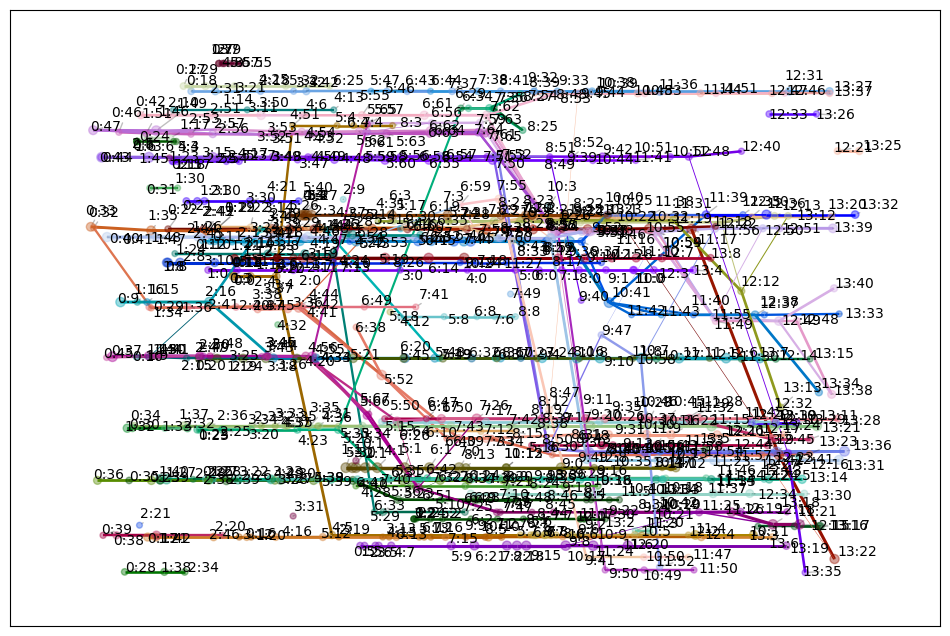

In [4]:
fig = scope.mappers[0].temporal_plot(layout_optimization='barycenter')

In [21]:
import networkx as nx
from copy import deepcopy

G = scope.mappers[0].G
pos = nx.get_node_attributes(G, 'ts_pos')
x_pos = {node:pos[node][0] for node in G.nodes()}
#y_pos = {pos[node][0] for node in G.nodes()}
#from temporalmapper.layout import component_ordered_layout
y_pos = component_ordered_layout(
    G,
    x_pos,
)
pos = {
    node:[x_pos[node],y_pos[node]] for node in G.nodes()
}
nx.draw(G,pos=pos)

KeyError: '0:0'

In [ ]:
nx.connected_components(G)

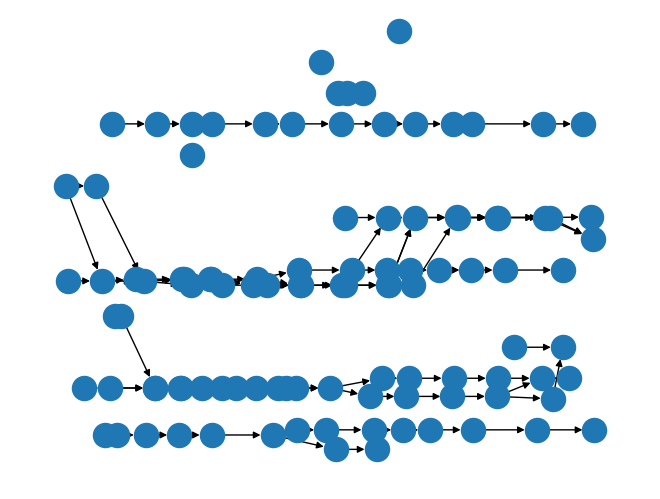

In [52]:
import networkx as nx
from copy import deepcopy

def construct_components(G):
    sources = [node for node in G.nodes() if G.in_degree(node)==0]
    components = {s:[] for s in sources}
    for node in G.nodes():
        shortest_source = node
        min_path = np.inf
        for s in sources:
            try:
                l = nx.shortest_path_length(G, source=s, target=node, weight='weight')
            except nx.NetworkXNoPath:
                l = np.inf
            if l < min_path:
                min_path = l
                shortest_source = s
        components[shortest_source].append(node)
    return components

def min_path_between_sets(G, cp1, cp2):
    G_quotient = deepcopy(G)
    
    cp1 = set(cp1)
    cp2 = set(cp2)
    
    # Ensure cp1 and cp2 don't overlap
    if cp1 & cp2:
        return 0
    
    # Create super-nodes for each set
    u = 'cp1_super'
    v = 'cp2_super'
    
    # Add super-nodes
    G_quotient.add_node(u)
    G_quotient.add_node(v)
    
    # Connect all vertices in cps to super-nodes with zero-weight edges
    for node in cp1:
        G_quotient.add_edge(u, node, weight=0)
    for node in cp2:
        G_quotient.add_edge(node, v, weight=0)

    try:
        path_length = nx.shortest_path_length(G_quotient, u, v, weight='weight')
        return path_length
    except nx.NetworkXNoPath:
        return np.inf      
        
import numpy as np
from collections import deque

def find_connected_components(distances):
    """
    Find groups of objects that are mutually reachable (finite distances).
    Returns list of lists, where each inner list contains indices of a connected component.
    """
    n = len(distances)
    visited = set()
    components = []
    
    for start in range(n):
        if start in visited:
            continue
        
        # BFS to find all reachable nodes from start
        component = []
        queue = deque([start])
        visited.add(start)
        
        while queue:
            node = queue.popleft()
            component.append(node)
            
            # Find all neighbors with finite distance
            for neighbor in range(n):
                if (neighbor not in visited and 
                    distances[node][neighbor] != np.inf):
                    visited.add(neighbor)
                    queue.append(neighbor)
        
        components.append(sorted(component))
    
    return components


def nearest_neighbor_ordering(distances, start=0):
    """
    Greedy algorithm: always go to the nearest unvisited object.
    
    Args:
        distances: NxN numpy array where distances[i][j] is distance from i to j
        start: starting object index
    
    Returns:
        numpy array of indices representing the ordering
    """
    n = len(distances)
    unvisited = set(range(n))
    current = start
    path = [current]
    unvisited.remove(current)
    
    while unvisited:
        # Vectorized: get distances to all unvisited nodes
        unvisited_list = list(unvisited)
        distances_to_unvisited = distances[current][unvisited_list]
        
        # Filter out infinite distances
        finite_mask = distances_to_unvisited != np.inf
        if not np.any(finite_mask):
            break  # No more reachable nodes
        
        nearest_idx = unvisited_list[np.argmin(
            np.where(finite_mask, distances_to_unvisited, np.inf)
        )]
        path.append(nearest_idx)
        unvisited.remove(nearest_idx)
        current = nearest_idx
    
    return np.array(path)


def best_nearest_neighbor(distances, component):
    """
    Try nearest neighbor from each starting point within a component, 
    return the best.
    
    Args:
        distances: Full NxN distance matrix
        component: List of indices in this component
    
    Returns:
        (best_path, best_distance) for this component
    """
    best_path = None
    best_distance = np.inf
    
    for start in component:
        path = nearest_neighbor_ordering(distances, start)
        
        if len(path) == 0:
            continue
        
        total = np.sum(distances[path[:-1], path[1:]])
        
        if total < best_distance:
            best_distance = total
            best_path = path
    
    return best_path, best_distance


def two_opt_fast(distances, path, max_iterations=1000):
    """
    Faster 2-opt using numpy vectorization for distance calculations.
    """
    def path_distance(p):
        if len(p) <= 1:
            return 0
        return np.sum(distances[p[:-1], p[1:]])
    
    path = np.array(path, dtype=int)
    improved = True
    iteration = 0
    
    while improved and iteration < max_iterations:
        improved = False
        best_improvement = 0
        best_i, best_j = None, None
        
        # Calculate all improvements at once
        for i in range(1, len(path) - 1):
            for j in range(i + 1, len(path)):
                # Change in distance from reversing path[i:j]
                # Only need to check the edges that change
                d1 = distances[path[i-1], path[i]] + distances[path[j-1], path[j]]
                d2 = distances[path[i-1], path[j-1]] + distances[path[i], path[j]]
                improvement = d1 - d2
                
                if improvement > best_improvement:
                    best_improvement = improvement
                    best_i, best_j = i, j
        
        if best_improvement > 0:
            path = np.concatenate([path[:best_i], path[best_i:best_j][::-1], path[best_j:]])
            improved = True
        
        iteration += 1
    
    return path


def arrange_components(G,cpts):
    n_cpts = len(cpts)
    distances = np.array(
        [[min_path_between_sets(G, cpts[cp1],cpts[cp2]) for cp2 in cpts] for cp1 in cpts]
    )
    # Find connected components
    components = find_connected_components(distances)
    #print(f"Found {len(components)} connected component(s): {components}")
    
    all_paths = []
    total_distance = 0
    
    # Optimize each component
    for component in components:
        #print(f"\nOptimizing component {component}...")
        
        if len(component) == 1:
            # Single object, no optimization needed
            path = np.array(component)
            all_paths.append(path)
            #print(f"  Single object: {path}")
        else:
            # Multi-start greedy
            path, greedy_dist = best_nearest_neighbor(distances, component)
            #print(f"  Greedy distance: {greedy_dist}")
            
            # Improve with 2-opt
            path = two_opt_fast(distances, path)
            component_distance = np.sum(distances[path[:-1], path[1:]])
            #print(f"  After 2-opt: {component_distance}")
            #print(f"  Path: {path}")
            
            all_paths.append(path)
            total_distance += component_distance
    
    # Concatenate all paths
    final_path = np.concatenate(all_paths)
    
    return final_path, total_distance, components


    if path is None:
        raise ValueError("No valid ordering found (some objects unreachable)")
    
    print(f"Greedy distance: {greedy_dist}")
    
    # Improve with 2-opt
    path = two_opt(distances, path)
    
    total_distance = np.sum(distances[path[:-1], path[1:]])
    
    return path, total_distance

def component_ordered_layout(G, x_positions, spacing=1):
    cpts = construct_components(G)
    order = np.concatenate(arrange_components(G, cpts)[2])
    y_pos = {}
    cpt_sources = list(cpts.keys())
    current_y_value = 0
    for i in order:
        s = cpt_sources[i]
        nodes = cpts[s]
        subgraph = G.subgraph(nodes).copy()
        cpt_y_pos = temporal_barycenter_layout(
            subgraph,
            x_positions,
            spacing=spacing,
        )
        cpt_min = np.min(np.array([
           cpt_y_pos[node] for node in nodes 
        ]))
        cpt_max = np.max(np.array([
            cpt_y_pos[node] for node in nodes
        ]))
        for node in nodes:
            y_pos[node] = cpt_y_pos[node]-cpt_min+current_y_value
        current_y_value += cpt_max-cpt_min + spacing
    return y_pos

            
        
G = scope.mappers[2].G
pos = nx.get_node_attributes(G, 'ts_pos')
x_pos = {node:pos[node][0] for node in G.nodes()}
#y_pos = {pos[node][0] for node in G.nodes()}
y_pos = component_ordered_layout(
    G,
    x_pos,
    spacing=5
)
pos = {
    node:[x_pos[node],y_pos[node]] for node in G.nodes()
}
nx.draw(G,pos=pos)

In [30]:
cpts = construct_components(G)

In [46]:
nodes = cpts['0:0']
subgraph = G.subgraph(nodes).copy()
print(initial_y_positions(subgraph))

{'0:0': 0, np.str_('1:1'): 0.0, np.str_('2:0'): 0.0, np.str_('3:0'): 0.0, np.str_('4:0'): 0.0, np.str_('5:3'): 0.0, np.str_('6:2'): -0.5, np.str_('7:4'): -0.5, np.str_('6:5'): 0.5, np.str_('7:6'): 0.5, np.str_('8:5'): 0.5, np.str_('9:4'): 0.5, np.str_('10:5'): 0.5, np.str_('11:4'): 0.5, np.str_('12:5'): 0.5, np.str_('13:4'): 0.5}


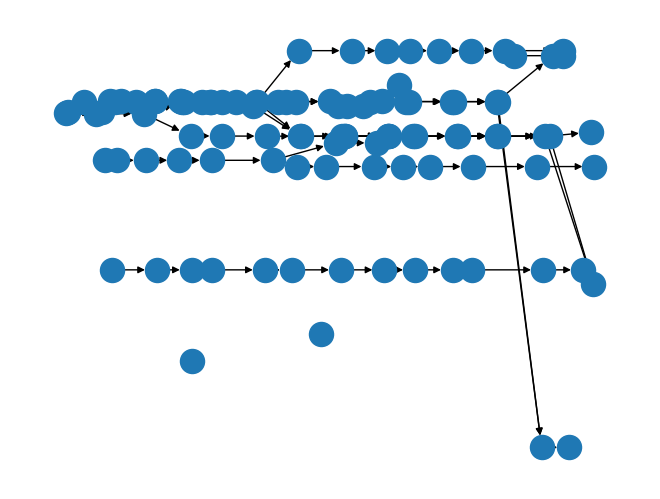

In [44]:
import networkx as nx

def initial_y_positions(G):
    # Find minimal arborescence (directed spanning tree)
    arb = nx.minimum_spanning_arborescence(G)
    
    # Find root nodes (nodes with in_degree 0 in arborescence)
    roots = [node for node in arb.nodes() if arb.in_degree(node) == 0]
    
    x_pos = {}
    y_pos = {}
    
    def layout_tree(node, x, y_start, y_spacing):
        x_pos[node] = x
        y_pos[node] = y_start
        
        # Get children of this node in arborescence
        children = list(arb.successors(node))
        
        if children:
            # Fan out children vertically
            num_children = len(children)
            y_offset = (num_children - 1) * y_spacing / 2
            
            for i, child in enumerate(children):
                child_y = y_start - y_offset + i * y_spacing
                layout_tree(child, x + 1, child_y, y_spacing)
    
    # Layout each tree rooted at root nodes
    y_current = 0
    for root in roots:
        layout_tree(root, x=0, y_start=y_current, y_spacing=1)
        # Update y_current for next tree
        y_current = max(y_pos.values()) + 2
    
    return y_pos


def temporal_barycenter_layout(
    G,
    x_positions,
    y_positions=None,
    iterations=1000,
    lr_init=0.8,
    lr_min=0.05,
    lr_max=1.0,
    momentum=0.8,
    tol=1e-4,
    decay=0.005,
    eps=1e-6,
    lambda_coparent=0.2,
    spacing=2,
):
    """
    Barycenter-based layout for edge-crossing minimization with:
    - adaptive learning rate
    - momentum
    - normalization
    - early stopping
    """

    def coparent_penalty(d, spacing=spacing):
        if d < spacing:
            return 0
        else:
            return d-spacing
    
    nodes = list(G.nodes())
    edge_weights = nx.get_edge_attributes(G, "weight")

    # --- Initialize y positions ---
    if y_positions is None:
        try:
            y_positions = initial_y_positions(G)
        except:
            # can happen if G is not connected
            y_positions = {n:np.random.random() for n in nodes}
    else:
        y_positions = dict(y_positions)

    # --- Velocity for momentum ---
    velocity = {n: 0.0 for n in nodes}
    coparent_force = {n: 0.0 for n in nodes}
    prev_avg_delta = None

    # --- Sanity check ---
    if not set(nodes).issubset(x_positions):
        raise ValueError("x_positions must contain all nodes")

    for it in range(iterations):
        new_y = {}
        total_delta = 0.0

        # --- Base learning rate ---
        lr = lr_init * np.exp(-decay * it)
        lr = np.clip(lr, lr_min, lr_max)

        # --- Compute barycenter attraction ---
        for node in nodes:
            yi = y_positions[node]
            xi = x_positions[node]
        
            neighbors = list(G.neighbors(node))
            #neighbors = list(G.predecessors(node))
            attraction = 0.0
        
            if neighbors:
                weighted_sum = 0.0
                weight_total = 0.0
        
                for nbr in neighbors:
                    dx = abs(xi - x_positions[nbr])
        
                    # --- Edge weight (default = 1.0 if missing) ---
                    ew = edge_weights.get((node, nbr),
                         edge_weights.get((nbr, node), 1.0))
        
                    # --- Combined weight: spatial + edge importance ---
                    w = ew / (dx + eps)
        
                    weighted_sum += w * y_positions[nbr]
                    weight_total += w
        
                target = weighted_sum / weight_total
                attraction = target - yi

            # --- Co-parent attraction ---
            parents = list(G.predecessors(node))
            if len(parents) >= 2:
                mean_y = np.mean([y_positions[p] for p in parents])
                total_weight = np.sum([
                    edge_weights.get((p,node)) for p in parents
                ])
                for p in parents:
                    w = edge_weights.get((p, node))/total_weight
                    coparent_force[p] += w * lambda_coparent * (mean_y - y_positions[p])
        
            # --- Momentum update ---
            cp_force = coparent_penalty(coparent_force[node])
            v = momentum * velocity[node] + lr * (attraction + cp_force)
            velocity[node] = v
        
            new_y[node] = yi + v
            total_delta += abs(v)


        # --- Normalize to prevent drift ---
        vals = np.array(list(new_y.values()))
        std = vals.std()
        if std > 0:
            mean = vals.mean()
            new_y = {n: (y - mean) / std for n, y in new_y.items()}

        avg_delta = total_delta / len(nodes)

        # --- Adaptive LR correction ---
        if prev_avg_delta is not None:
            if avg_delta > prev_avg_delta:
                lr_init *= 0.7
            else:
                lr_init *= 1.05
            lr_init = np.clip(lr_init, lr_min, lr_max)

        y_positions = new_y
        prev_avg_delta = avg_delta

        # --- Early stopping ---
        if avg_delta < tol:
            break

    return y_positions

G = scope.mappers[2].G
pos = nx.get_node_attributes(G, 'ts_pos')
x_pos = {node:pos[node][0] for node in G.nodes()}
#y_pos = {pos[node][0] for node in G.nodes()}
y_pos = temporal_barycenter_layout(
    G,
    x_pos,
)
pos = {
    node:[x_pos[node],y_pos[node]] for node in G.nodes()
}
nx.draw(G,pos=pos)

In [112]:
import plotly.express as px
def slice_treemap(mapper, idx=None):
    if idx is None:
        dfs = []
        for idx in range(mapper.N_checkpoints):
            dfs.append(slice_df(mapper, idx))
        dataframe = pd.concat(dfs, ignore_index=True) 
        path = ['slice', 'node']
    else:
        dataframe = slice_df(mapper, idx)
        path = ['node']

    fig = px.treemap(
        dataframe,
        path=path,
        values='count',
        color='growth',
        color_continuous_scale='RdYlGn',
        color_continuous_midpoint=0,
    )

    fig.update_traces(
        hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Growth: %{color:.2f}'
    )

    return fig


def slice_df(mapper, idx):
    G = mapper.G
    counts = nx.get_node_attributes(G, 'count')
    growth = nx.get_node_attributes(G, 'growth')
    
    nodes = nodes_in_slice(mapper, idx)
    top_n = 5

    count_values = np.array([
        counts[v] for v in nodes    
    ])
    growth_values = np.array([
        growth[v] for v in nodes
    ])
    slice_df = pd.DataFrame({
        'node':nodes,
        'slice':[idx]*len(nodes),
        'count':count_values,
        'growth':growth_values,
    })
    return slice_df

slice_treemap(scope.mappers[0])


NameError: name 'nodes_in_slice' is not defined

In [110]:
def treemap(scope, idx=0):
    outer_dfs = []
    for i in range(scope.n_layers):
        mapper = scope.mappers[i]
        dataframe = slice_df(mapper, idx)
        path = ['layer','node']
        dataframe['layer']=i
        outer_dfs.append(dataframe)
    dataframe = pd.concat(outer_dfs, ignore_index=True)
    fig = px.treemap(
        dataframe,
        path=path,
        values='count',
        color='growth',
        color_continuous_scale='RdYlGn',
        color_continuous_midpoint=0,
    )

    fig.update_traces(
        hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Growth: %{color:.2f}'
    )
    return fig

treemap(scope, 1)

NameError: name 'slice_df' is not defined

In [43]:
scope.toponymies

{}